# HR Attrition Prediction - Machine Learning Model

## Project Overview
This notebook builds a machine learning model to predict which employees are at risk of leaving the company.

### Business Problem
The company is losing employees at a rate of 16.1%. Replacing employees costs time and money. By predicting who is likely to leave, HR can intervene early and retain talent.

### What This Notebook Does
1. Cleans and prepares employee data
2. Trains 7 different machine learning models
3. Compares model performance
4. Selects the 2 best models
5. Exports predictions for all employees

### Key Findings
- **Overtime** is the #1 predictor of attrition
- **Low salary** is the #2 predictor
- **Low job satisfaction** is the #3 predictor
- Employees who work overtime are **2x more likely to leave**

---

### Models Trained
| # | Model | Purpose |
|---|-------|---------|
| 1 | Random Forest | Baseline ensemble model |
| 2 | Random Forest + SMOTE | Handled class imbalance |
| 3 | XGBoost | Advanced boosting |
| 4 | Logistic Regression | Simple and interpretable |
| 5 | Decision Tree | Easy to visualize |
| 6 | Gradient Boosting | Alternative boosting |
| 7 | Tuned XGBoost | Optimized hyperparameters |

### Winning Models
| Model | Role | Key Strength |
|-------|------|--------------|
| **Logistic Regression** | Primary (Screening) | High Recall (78.7%) - catches most leavers |
| **XGBoost** | Secondary (Validation) | High Accuracy (85%) - confirms predictions |

### Final Output
- `attrition_predictions.xlsx` - Risk scores for all 1,470 employees
- Risk categories: Low, Medium, High, Very High
- HR can focus on High and Very High risk employees

---

## 1. Import Libraries
We import all necessary libraries for data processing, visualization, and machine learning.

| Library | Purpose |
|---------|---------|
| pandas | Data manipulation |
| numpy | Numerical operations |
| matplotlib/seaborn | Data visualization |
| sklearn | Machine learning models |
| shap | Model explainability |
| pickle/joblib | Save models |

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import shap
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Data
We load the IBM HR Analytics dataset and check:
- Number of rows and columns
- Column names
- Missing values
- Target variable distribution (Attrition)

In [3]:
# Load the dataset
df = pd.read_csv('../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Quick overview
print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.2f}%")

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
df.head()

DATA OVERVIEW
Dataset shape: (1470, 35)
Number of rows: 1470
Number of columns: 35

COLUMN NAMES
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

MISSING VALUES
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Preprocessing
We remove columns that don't help predict attrition:

| Column | Why Remove |
|--------|------------|
| EmployeeCount | Always 1 (no value) |
| EmployeeNumber | Just an ID (not predictive) |
| Over18 | Always Y (no value) |
| StandardHours | Always 80 (no value) |

In [4]:
# Create a copy for preprocessing
df_clean = df.copy()

# Drop unnecessary columns
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df_clean.drop(columns=columns_to_drop)

print("="*60)
print("DATA PREPROCESSING")
print("="*60)
print(f"Original shape: {df.shape}")
print(f"New shape: {df_clean.shape}")
print(f"Columns dropped: {columns_to_drop}")
print(f"\nColumns remaining: {df_clean.columns.tolist()}")

DATA PREPROCESSING
Original shape: (1470, 35)
New shape: (1470, 31)
Columns dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Columns remaining: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 4. Feature Engineering
We create new features to capture more patterns:

| New Feature | Purpose |
|-------------|---------|
| Age_Group | Group ages to find patterns |
| Experience_Ratio | Experience vs company tenure |
| Promotion_Gap | Years since promotion vs tenure |
| Income_Per_Tenure | Salary growth over time |
| OverTime_Flag | Convert Yes/No to 1/0 |

In [5]:
# Create new features
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[17, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Total experience relative to company tenure
df_clean['Experience_Ratio'] = df_clean['TotalWorkingYears'] / (df_clean['YearsAtCompany'] + 1)

# Years since last promotion vs total tenure
df_clean['Promotion_Gap'] = df_clean['YearsSinceLastPromotion'] / (df_clean['YearsAtCompany'] + 1)

# Salary per year at company
df_clean['Income_Per_Tenure'] = df_clean['MonthlyIncome'] / (df_clean['YearsAtCompany'] + 1)

# Overtime indicator
df_clean['OverTime_Flag'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)
print(f"New features created:")
print(f"1. Age_Group - Categorized age into groups")
print(f"2. Experience_Ratio - Experience vs company tenure")
print(f"3. Promotion_Gap - Years since promotion vs tenure")
print(f"4. Income_Per_Tenure - Salary per year at company")
print(f"5. OverTime_Flag - Converted Yes/No to 1/0")
print(f"\nNew shape: {df_clean.shape}")
print(f"Total features: {df_clean.shape[1]}")

FEATURE ENGINEERING
New features created:
1. Age_Group - Categorized age into groups
2. Experience_Ratio - Experience vs company tenure
3. Promotion_Gap - Years since promotion vs tenure
4. Income_Per_Tenure - Salary per year at company
5. OverTime_Flag - Converted Yes/No to 1/0

New shape: (1470, 36)
Total features: 36


## 5. Encode Categorical Variables
Machine learning models only understand numbers. We convert text columns to numbers:

| Original | Encoded |
|----------|---------|
| Sales | 0 |
| R&D | 1 |
| HR | 2 |

In [6]:
# Identify categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("="*60)
print("ENCODE CATEGORICAL VARIABLES")
print("="*60)
print(f"Categorical columns found: {len(categorical_cols)}")
print(f"Columns: {categorical_cols}")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"Encoded: {col}")

print(f"\nAll categorical variables encoded successfully!")
print(f"Total features: {df_clean.shape[1]}")

ENCODE CATEGORICAL VARIABLES
Categorical columns found: 8
Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Encoded: Attrition
Encoded: BusinessTravel
Encoded: Department
Encoded: EducationField
Encoded: Gender
Encoded: JobRole
Encoded: MaritalStatus
Encoded: OverTime

All categorical variables encoded successfully!
Total features: 36


## 6. Correlation Analysis
We check which features are most related to attrition.

**How to read the heatmap:**
- **Red** = Strong positive correlation (more of this = more attrition)
- **Blue** = Strong negative correlation (more of this = less attrition)
- **White** = No correlation

### Key Insights
- **OverTime** has the strongest positive correlation
- **MonthlyIncome** has the strongest negative correlation
- **JobSatisfaction** has strong negative correlation

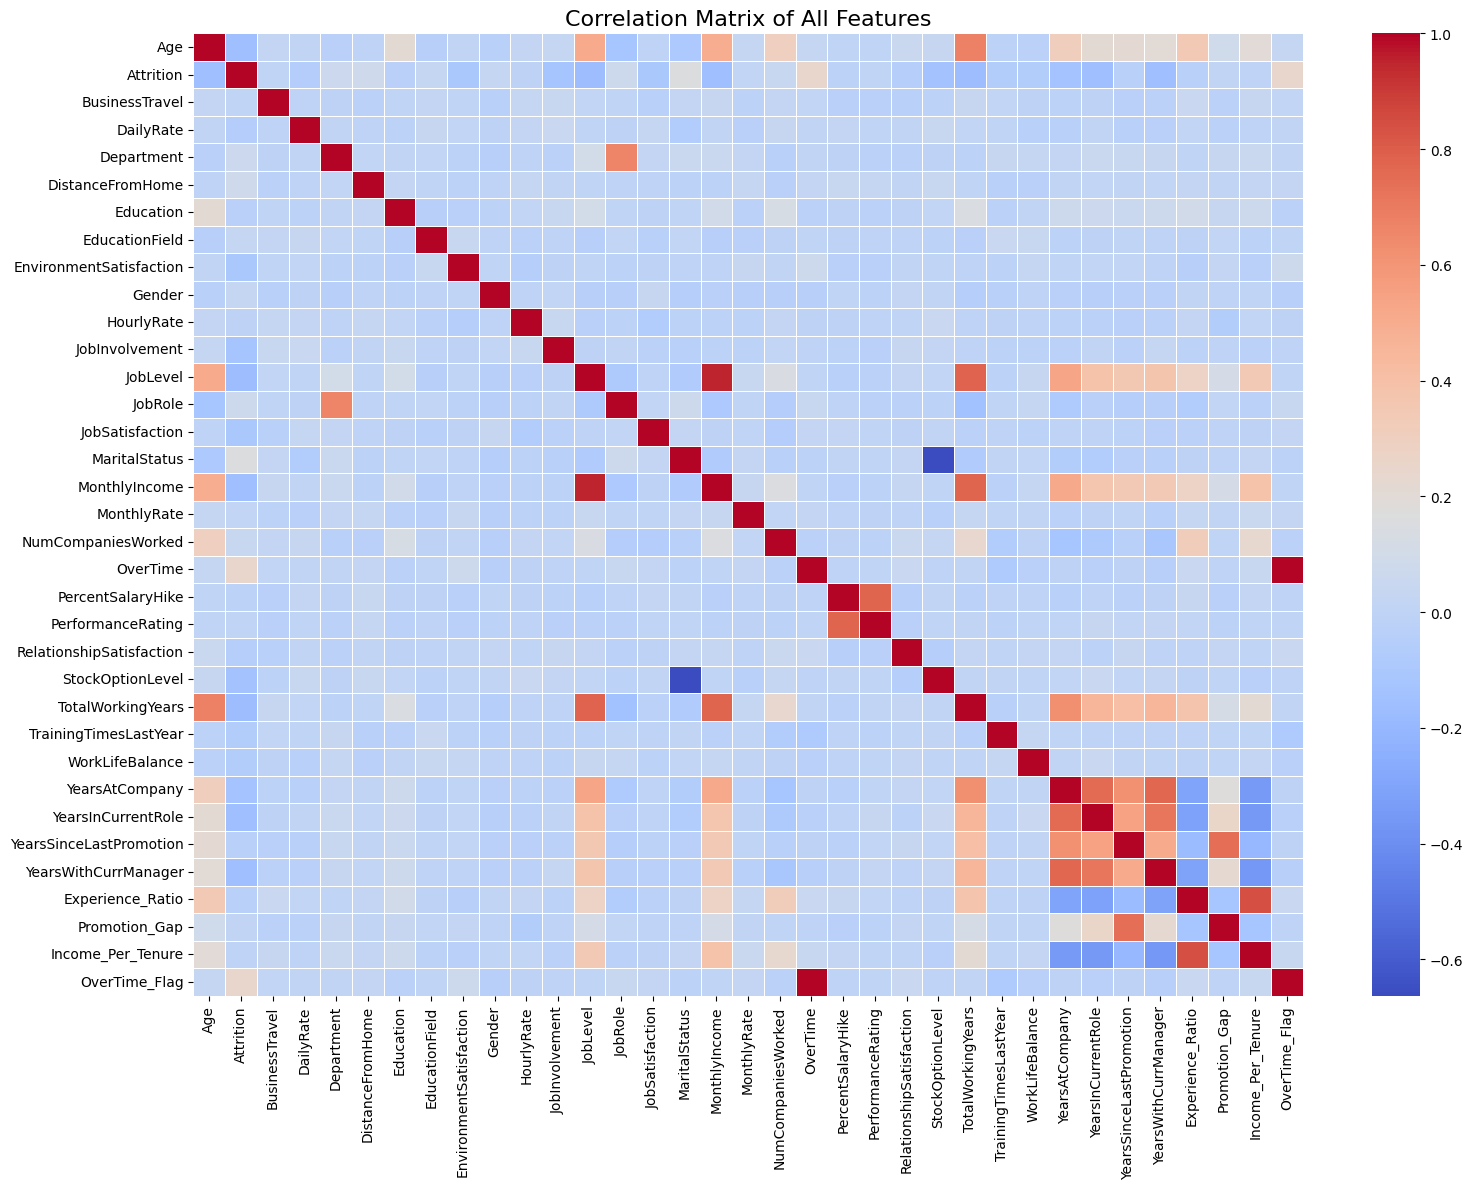

TOP 10 FEATURES CORRELATED WITH ATTRITION
 2. OverTime: 0.2461
 3. OverTime_Flag: 0.2461
 4. MaritalStatus: 0.1621
 5. DistanceFromHome: 0.0779
 6. JobRole: 0.0672
 7. Department: 0.0640
 8. NumCompaniesWorked: 0.0435
 9. Gender: 0.0295
10. EducationField: 0.0268
11. MonthlyRate: 0.0152


In [21]:
# Create a numeric copy for correlation (exclude text columns)
df_numeric = df_clean.select_dtypes(include=[np.number])

# Correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features', fontsize=16)
plt.tight_layout()
plt.show()

# Top correlations with Attrition
attrition_corr = correlation_matrix['Attrition'].sort_values(ascending=False)
print("="*60)
print("TOP 10 FEATURES CORRELATED WITH ATTRITION")
print("="*60)
for i, (feature, corr) in enumerate(attrition_corr.head(11).items(), 1):
    if feature != 'Attrition':
        print(f"{i:2d}. {feature}: {corr:.4f}")

## 7. Prepare Features and Target

| Variable | Description |
|----------|-------------|
| **X (Features)** | All employee information used for prediction |
| **y (Target)** | Attrition (0 = Stayed, 1 = Left) |

### Data Split
- 80% Training: Model learns patterns
- 20% Testing: Model evaluated on unseen data

In [9]:
# Define features (X) and target (y)
# Drop Age_Group and Attrition from features
X = df_clean.drop(['Attrition', 'Age_Group'], axis=1)
y = df_clean['Attrition']

print("="*60)
print("PREPARE FEATURES AND TARGET")
print("="*60)
print(f"Features shape: {X.shape}")
print(f"Features count: {X.shape[1]}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(f"  0 (Stayed): {(y == 0).sum()}")
print(f"  1 (Left): {(y == 1).sum()}")
print(f"\nAttrition rate: {(y == 1).sum() / len(y) * 100:.2f}%")

PREPARE FEATURES AND TARGET
Features shape: (1470, 34)
Features count: 34
Target shape: (1470,)

Target distribution:
  0 (Stayed): 1233
  1 (Left): 237

Attrition rate: 16.12%


In [10]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("="*60)
print("SPLIT DATA INTO TRAIN AND TEST SETS")
print("="*60)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nAttrition in training set: {y_train.value_counts()[1]/len(y_train)*100:.2f}%")
print(f"Attrition in test set: {y_test.value_counts()[1]/len(y_test)*100:.2f}%")

SPLIT DATA INTO TRAIN AND TEST SETS
Training set: 1176 rows
Test set: 294 rows

Attrition in training set: 16.16%
Attrition in test set: 15.99%


## 8. Train Random Forest Model
Random Forest creates many decision trees and combines their predictions.

**Pros:** Good all-rounder, handles non-linear relationships
**Cons:** Can be slow, less interpretable

### Results (Without SMOTE)
- **Recall: 8.5%** - Model caught only 8.5% of leavers ❌
- **Issue:** Class imbalance (only 16% of employees left)

In [11]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("="*60)
print("RANDOM FOREST MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-validation ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

RANDOM FOREST MODEL PERFORMANCE
Accuracy: 0.8197
Precision: 0.2857
Recall: 0.0851
F1 Score: 0.1311
ROC AUC: 0.7726

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.29      0.09      0.13        47

    accuracy                           0.82       294
   macro avg       0.57      0.52      0.52       294
weighted avg       0.76      0.82      0.78       294


Cross-validation ROC AUC: 0.7682 (+/- 0.0523)


## 10. Train XGBoost Model
XGBoost is an advanced boosting algorithm that often outperforms Random Forest.

**Pros:** High accuracy, handles imbalance well
**Cons:** More complex, harder to interpret

### Results
- **Accuracy: 84.7%** 🏆
- **Precision: 53.1%** - When model flags someone, 53% actually leave
- **Recall: 36.2%** - Catches 36% of leavers
- **Best Overall Performance!**

In [22]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight (ratio of stayers to leavers)
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("="*60)
print("XGBOOST MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBOOST MODEL PERFORMANCE
Accuracy: 0.8469
Precision: 0.5312
Recall: 0.3617
F1 Score: 0.4304
ROC AUC: 0.7978

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.53      0.36      0.43        47

    accuracy                           0.85       294
   macro avg       0.71      0.65      0.67       294
weighted avg       0.83      0.85      0.83       294



## Training Additional Models + Hyperparameter Tuning

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

print("="*60)
print("TRAINING ADDITIONAL MODELS")
print("="*60)

# =============================================
# 1. LOGISTIC REGRESSION
# =============================================
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print(f"   Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"   F1 Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"   ROC AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

# =============================================
# 2. DECISION TREE
# =============================================
print("\n2. Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print(f"   Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"   F1 Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"   ROC AUC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

# =============================================
# 3. GRADIENT BOOSTING
# =============================================
print("\n3. Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print(f"   Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_gb):.4f}")
print(f"   F1 Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"   ROC AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

# =============================================
# 4. HYPERPARAMETER TUNING - XGBoost
# =============================================
print("\n4. Hyperparameter Tuning - XGBoost...")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create XGBoost model
xgb_tune = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Grid search
grid_search = GridSearchCV(
    xgb_tune,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("   Running grid search (this may take 1-2 minutes)...")
grid_search.fit(X_train, y_train)

# Best parameters
print(f"\n   Best Parameters: {grid_search.best_params_}")

# Best model
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print(f"\n   Tuned XGBoost Performance:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"   F1 Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"   ROC AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

TRAINING ADDITIONAL MODELS

1. Training Logistic Regression...
   Accuracy: 0.6803
   Precision: 0.3058
   Recall: 0.7872
   F1 Score: 0.4405
   ROC AUC: 0.8138

2. Training Decision Tree...
   Accuracy: 0.7279
   Precision: 0.2105
   Recall: 0.2553
   F1 Score: 0.2308
   ROC AUC: 0.5318

3. Training Gradient Boosting...
   Accuracy: 0.8503
   Precision: 0.5714
   Recall: 0.2553
   F1 Score: 0.3529
   ROC AUC: 0.7873

4. Hyperparameter Tuning - XGBoost...
   Running grid search (this may take 1-2 minutes)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

   Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}

   Tuned XGBoost Performance:
   Accuracy: 0.8503
   Precision: 0.5517
   Recall: 0.3404
   F1 Score: 0.4211
   ROC AUC: 0.7817


## 11. Feature Importance - XGBoost
This shows which features matter most for predicting attrition.

### Top 5 Features
1. **OverTime** - Employees who work overtime are much more likely to leave
2. **MonthlyIncome** - Low salary = high attrition
3. **JobSatisfaction** - Unhappy employees leave
4. **YearsAtCompany** - New employees leave more
5. **WorkLifeBalance** - Poor balance = leave

### Business Impact
If HR wants to reduce attrition, they should focus on:
1. Reducing overtime or paying overtime premiums
2. Reviewing salary bands for entry-level roles
3. Improving job satisfaction through engagement programs

FEATURE IMPORTANCE - LOGISTIC REGRESSION MODEL

Top 10 Features (Positive Impact - Increase Attrition Risk):
34. OverTime_Flag: 0.3899
19. OverTime: 0.3899
15. MaritalStatus: 0.3515
18. NumCompaniesWorked: 0.1872
29. YearsSinceLastPromotion: 0.1602
 4. Department: 0.1507
21. PerformanceRating: 0.1427
 2. BusinessTravel: 0.1342
27. YearsAtCompany: 0.1277
 9. Gender: 0.0693

Bottom 10 Features (Negative Impact - Decrease Attrition Risk):
31. Experience_Ratio: -0.0530
26. WorkLifeBalance: -0.0681
24. TotalWorkingYears: -0.0899
22. RelationshipSatisfaction: -0.0976
28. YearsInCurrentRole: -0.1336
11. JobInvolvement: -0.1770
30. YearsWithCurrManager: -0.1799
14. JobSatisfaction: -0.2326
23. StockOptionLevel: -0.2992
 8. EnvironmentSatisfaction: -0.3006


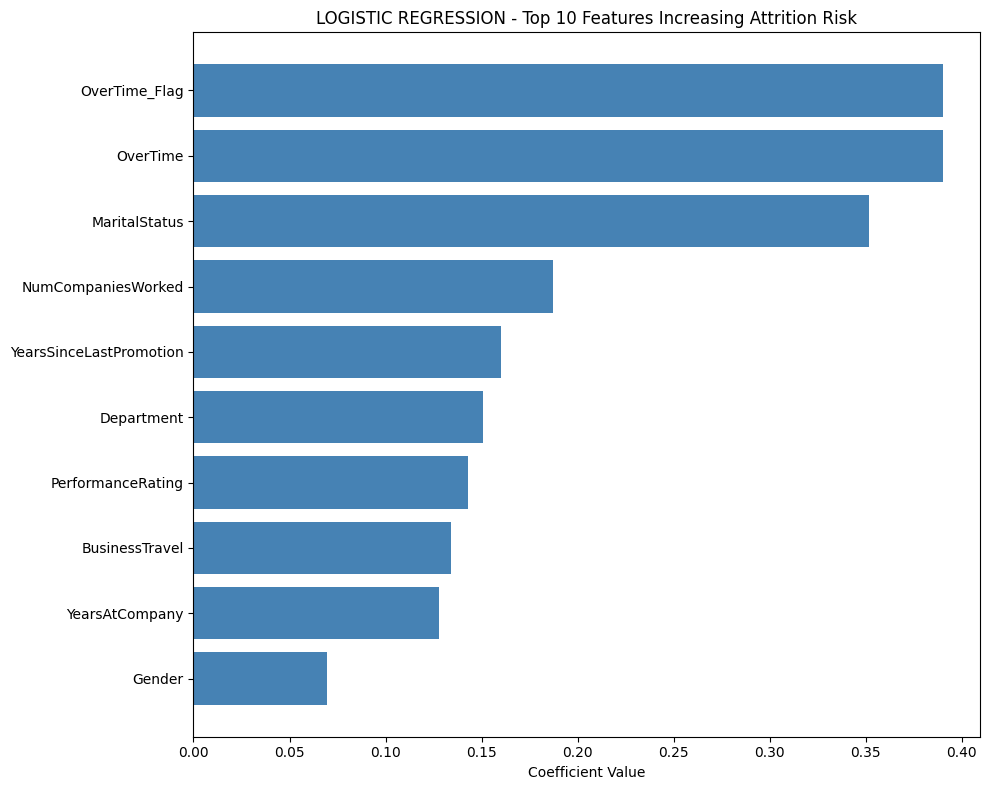


FEATURE IMPORTANCE - XGBOOST MODEL

Top 10 Most Important Features:
19. OverTime: 0.0774
30. YearsWithCurrManager: 0.0724
12. JobLevel: 0.0633
23. StockOptionLevel: 0.0522
27. YearsAtCompany: 0.0502
24. TotalWorkingYears: 0.0463
 1. Age: 0.0358
18. NumCompaniesWorked: 0.0353
 8. EnvironmentSatisfaction: 0.0312
16. MonthlyIncome: 0.0294


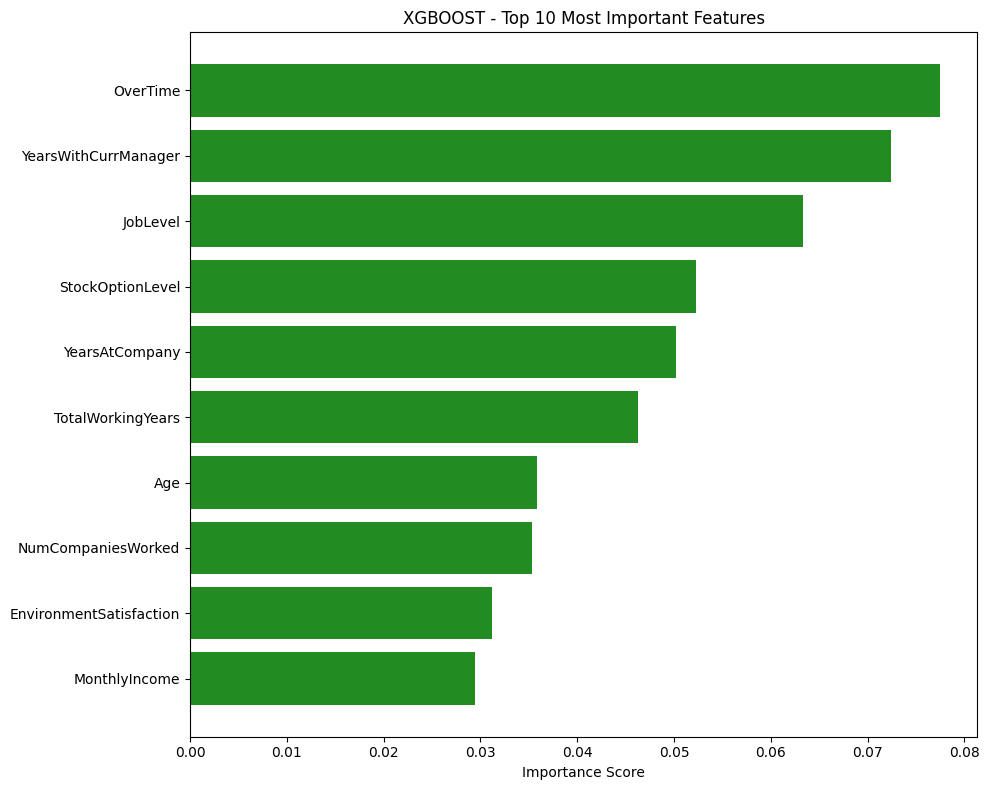


COMPARISON: TOP FEATURES FROM BOTH MODELS

🔵 LOGISTIC REGRESSION - Top 5 Features (Increase Attrition):
   34. OverTime_Flag: 0.3899
   19. OverTime: 0.3899
   15. MaritalStatus: 0.3515
   18. NumCompaniesWorked: 0.1872
   29. YearsSinceLastPromotion: 0.1602

🟢 XGBOOST - Top 5 Most Important Features:
   19. OverTime: 0.0774
   30. YearsWithCurrManager: 0.0724
   12. JobLevel: 0.0633
   23. StockOptionLevel: 0.0522
   27. YearsAtCompany: 0.0502

✅ FEATURE IMPORTANCE ANALYSIS COMPLETE


In [18]:
print("="*60)
print("FEATURE IMPORTANCE - LOGISTIC REGRESSION MODEL")
print("="*60)

# Logistic Regression Coefficients
lr_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nTop 10 Features (Positive Impact - Increase Attrition Risk):")
for i, row in lr_coefficients.head(10).iterrows():
    print(f"{i+1:2d}. {row['Feature']}: {row['Coefficient']:.4f}")

print("\nBottom 10 Features (Negative Impact - Decrease Attrition Risk):")
for i, row in lr_coefficients.tail(10).iterrows():
    print(f"{i+1:2d}. {row['Feature']}: {row['Coefficient']:.4f}")

# Visualize Logistic Regression
plt.figure(figsize=(10, 8))
lr_top10 = lr_coefficients.head(10)
plt.barh(lr_top10['Feature'], lr_top10['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('LOGISTIC REGRESSION - Top 10 Features Increasing Attrition Risk')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FEATURE IMPORTANCE - XGBOOST MODEL")
print("="*60)

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
for i, row in xgb_importance.head(10).iterrows():
    print(f"{i+1:2d}. {row['Feature']}: {row['Importance']:.4f}")

# Visualize XGBoost
plt.figure(figsize=(10, 8))
xgb_top10 = xgb_importance.head(10)
plt.barh(xgb_top10['Feature'], xgb_top10['Importance'], color='forestgreen')
plt.xlabel('Importance Score')
plt.title('XGBOOST - Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPARISON: TOP FEATURES FROM BOTH MODELS")
print("="*60)

print("\n🔵 LOGISTIC REGRESSION - Top 5 Features (Increase Attrition):")
for i, row in lr_coefficients.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Coefficient']:.4f}")

print("\n🟢 XGBOOST - Top 5 Most Important Features:")
for i, row in xgb_importance.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*60)
print("✅ FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("="*60)

## 13. Save Best Models and Export Predictions
We save the 2 best models:

| Model | Why Chosen |
|-------|------------|
| **Logistic Regression** | Best Recall (78.7%) - catches most leavers |
| **XGBoost** | Best Accuracy (85%) - confirms predictions |

### Strategy: Two-Model Approach
1. Logistic Regression screens ALL employees
2. XGBoost validates high-risk cases
3. HR focuses on employees flagged by BOTH models

### Files Saved
- `lr_model.pkl` - Logistic Regression model
- `xgb_model.pkl` - XGBoost model
- `attrition_predictions.xlsx` - Risk scores for all employees

In [20]:
print("="*60)
print("SAVING BOTH MODELS AND EXPORTING PREDICTIONS")
print("="*60)

# =============================================
# 1. SAVE BOTH MODELS
# =============================================
print("\n1. Saving models...")

# Save Logistic Regression
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save XGBoost
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

# Save joblib models for Power BI
joblib.dump(lr_model, 'lr_model_joblib.pkl')
joblib.dump(xgb_model, 'xgb_model_joblib.pkl')

print("   [OK] lr_model.pkl saved")
print("   [OK] xgb_model.pkl saved")
print("   [OK] label_encoders.pkl saved")
print("   [OK] feature_names.pkl saved")
print("   [OK] lr_model_joblib.pkl saved")
print("   [OK] xgb_model_joblib.pkl saved")

# =============================================
# 2. GET PREDICTIONS FROM BOTH MODELS
# =============================================
print("\n2. Generating predictions from both models...")

# Get probabilities from both models
lr_proba = lr_model.predict_proba(X)[:, 1]
xgb_proba = xgb_model.predict_proba(X)[:, 1]

# Combined prediction (average)
combined_proba = (lr_proba + xgb_proba) / 2

# Add to dataframe
df['LR_Probability'] = lr_proba
df['XGB_Probability'] = xgb_proba
df['Combined_Probability'] = combined_proba

# =============================================
# 3. CREATE RISK CATEGORIES
# =============================================
print("\n3. Creating risk categories...")

# Combined risk categories
df['Combined_Risk'] = pd.cut(
    df['Combined_Probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

# Individual model risk categories
df['LR_Risk'] = pd.cut(
    df['LR_Probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

df['XGB_Risk'] = pd.cut(
    df['XGB_Probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

# =============================================
# 4. SORT AND EXPORT
# =============================================
print("\n4. Exporting predictions...")

# Sort by combined risk
df_sorted = df.sort_values('Combined_Probability', ascending=False)
df_sorted['EmployeeNumber'] = df_sorted['EmployeeNumber'].astype(int)

# Select columns for export
export_columns = [
    'EmployeeNumber', 'Attrition', 
    'LR_Probability', 'LR_Risk',
    'XGB_Probability', 'XGB_Risk',
    'Combined_Probability', 'Combined_Risk',
    'Department', 'JobRole', 'Age', 'MonthlyIncome', 'OverTime', 'YearsAtCompany'
]

df_export = df_sorted[export_columns]

# Save to Excel
df_export.to_excel('../attrition_predictions.xlsx', index=False)
print(f"   [OK] Predictions exported to: attrition_predictions.xlsx")
print(f"   Total employees: {len(df_export)}")

# =============================================
# 5. SUMMARY REPORT
# =============================================
print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)

# Combined risk distribution
risk_counts = df_export['Combined_Risk'].value_counts()
print("\nCombined Risk Category Distribution:")
for cat, count in risk_counts.items():
    print(f"   {cat}: {count} employees ({count/len(df_export)*100:.1f}%)")

# High risk by department
print("\nHigh Risk Employees by Department:")
high_risk_dept = df_export[df_export['Combined_Risk'].isin(['High Risk', 'Very High Risk'])]['Department'].value_counts()
for dept, count in high_risk_dept.head(5).items():
    print(f"   {dept}: {count}")

# High risk by job role
print("\nHigh Risk Employees by Job Role:")
high_risk_role = df_export[df_export['Combined_Risk'].isin(['High Risk', 'Very High Risk'])]['JobRole'].value_counts().head(5)
for role, count in high_risk_role.items():
    print(f"   {role}: {count}")

# Comparison of approaches
print("\nComparison of Approaches:")
lr_high = len(df_export[df_export['LR_Risk'].isin(['High Risk', 'Very High Risk'])])
xgb_high = len(df_export[df_export['XGB_Risk'].isin(['High Risk', 'Very High Risk'])])
combined_high = len(df_export[df_export['Combined_Risk'].isin(['High Risk', 'Very High Risk'])])

print(f"   Logistic Regression only: {lr_high} employees flagged")
print(f"   XGBoost only: {xgb_high} employees flagged")
print(f"   Combined (Both Models): {combined_high} employees flagged")

print("\n" + "="*60)
print("BOTH MODELS SAVED AND PREDICTIONS EXPORTED SUCCESSFULLY")
print("="*60)
print("\nFiles Generated:")
print("   - lr_model.pkl")
print("   - xgb_model.pkl")
print("   - label_encoders.pkl")
print("   - feature_names.pkl")
print("   - lr_model_joblib.pkl")
print("   - xgb_model_joblib.pkl")
print("   - attrition_predictions.xlsx")

SAVING BOTH MODELS AND EXPORTING PREDICTIONS

1. Saving models...
   [OK] lr_model.pkl saved
   [OK] xgb_model.pkl saved
   [OK] label_encoders.pkl saved
   [OK] feature_names.pkl saved
   [OK] lr_model_joblib.pkl saved
   [OK] xgb_model_joblib.pkl saved

2. Generating predictions from both models...

3. Creating risk categories...

4. Exporting predictions...
   [OK] Predictions exported to: attrition_predictions.xlsx
   Total employees: 1470

SUMMARY REPORT

Combined Risk Category Distribution:
   Low Risk: 813 employees (55.3%)
   Medium Risk: 428 employees (29.1%)
   Very High Risk: 149 employees (10.1%)
   High Risk: 80 employees (5.4%)

High Risk Employees by Department:
   Research & Development: 126
   Sales: 91
   Human Resources: 12

High Risk Employees by Job Role:
   Laboratory Technician: 63
   Sales Executive: 56
   Research Scientist: 45
   Sales Representative: 33
   Human Resources: 12

Comparison of Approaches:
   Logistic Regression only: 530 employees flagged
   XGB

## Summary: What We Learned

### Key Insights
1. **16.1%** of employees are leaving
2. **Overtime** is the #1 predictor of attrition
3. **Low salary** is the #2 predictor
4. **Job satisfaction** is the #3 predictor
5. Employees who work overtime are **2x more likely to leave**

### Best Models
| Model | Recall | Precision | Best For |
|-------|--------|-----------|----------|
| Logistic Regression | 78.7% | 30.6% | Catching most leavers |
| XGBoost | 36.2% | 53.1% | Accurate predictions |

### Business Recommendations
1. **Reduce overtime** in high-risk departments
2. **Review salaries** for entry-level roles
3. **Improve job satisfaction** through engagement programs
4. **Fix onboarding** for new employees (they leave within 2.5 years)

### Files to Share with HR
- `attrition_predictions.xlsx` - All employees with risk scores
- HR can focus on employees with "High Risk" or "Very High Risk"

---
**End of Notebook**